# Ligand-receptor binding

Simulations use [bngsim](https://bngsim.readthedocs.io), which loads BioNetGen models directly and runs ODE and stochastic (SSA) simulations in-process. `bngsim.Model.from_bngl` generates the reaction network with BioNetGen and loads it; the `simulate` actions at the end of the `.bngl` file are not run.

Two things to remember:
- Parameters are changed on the **model** (`model.set_param`), and simulations are run by a **simulator** (`sim.run`).
- A run starts from the model's *current* state. Call `model.reset()` before each run to start from the initial conditions (this also applies new initial-condition parameters such as `L0`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bngsim

# Load model from BNGL
infile = "../models/lr_init.bngl"
model = bngsim.Model.from_bngl(infile)
sim = bngsim.Simulator(model, method="ode")

# Remember the default parameter values so we can restore them
defaults = {p: model.get_param(p) for p in model.primary_param_names}

## Run a single simulation and plot the results

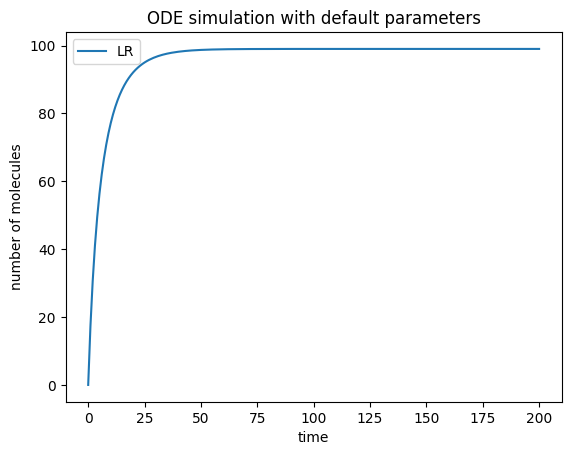

In [2]:
onames = model.observable_names

model.reset()
res1 = sim.run(t_span=(0, 200), n_points=201)

# Plot observables
for o in onames:
    plt.plot(res1.time, res1.observables[o], label=o)
plt.title("ODE simulation with default parameters")
plt.xlabel("time")
plt.ylabel("number of molecules")
_ = plt.legend()

In [3]:
print("parameters: ", model.primary_param_names)
print("species:    ", model.species_names)
print("observables:", model.observable_names)
print("reactions:  ", model.n_reactions)

parameters:  ['kp1', 'km1', 'L0']
species:     ['L(r)', 'R(l)', 'L(r!1).R(l!1)']
observables: ['LR']
reactions:   2


## Compare results of several simulations

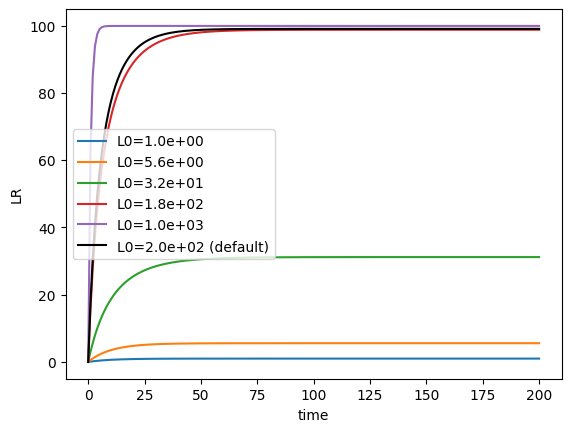

In [4]:
pname = 'L0'
o = 'LR'
for k in np.logspace(0, 3, 5):
    model.set_param(pname, k)
    model.reset()                      # apply the new initial condition
    res2 = sim.run(t_span=(0, 200), n_points=201)
    plt.plot(res2.time, res2.observables[o], label=f'{pname}={k:0.1e}')
plt.plot(res1.time, res1.observables[o], 'k', label=f'{pname}={defaults[pname]:0.1e} (default)')
model.set_param(pname, defaults[pname])  # restore the default
plt.xlabel("time")
plt.ylabel(o)
_ = plt.legend(loc='best')

## Scan the initial concentration of ligand and plot the steady-state value

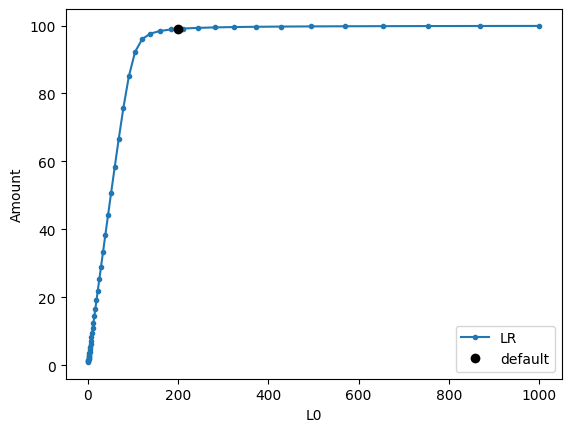

In [5]:
pname = 'L0'
o = 'LR'
out = []
krange = np.logspace(0, 3, 50)
for k in krange:
    model.set_param(pname, k)
    # Must reset AFTER changing an initial condition.
    model.reset()
    res2 = sim.run(t_span=(0, 200), n_points=201)
    out.append(res2.observables[o][-1])
model.set_param(pname, defaults[pname])

plt.plot(krange, out, '.-', label=o)
plt.plot(defaults[pname], res1.observables[o][-1], 'ko', label='default')
plt.xlabel(pname)
plt.ylabel('Amount')
_ = plt.legend(loc='best')

## Stochastic simulation

The same model can be simulated with the stochastic simulation algorithm (SSA), which tracks individual molecules. Each run gives a different trajectory; `run_replicates` runs many of them with seeds `seed, seed+1, ...`, so the results are reproducible. The ODE solution is close to the average of many stochastic trajectories.

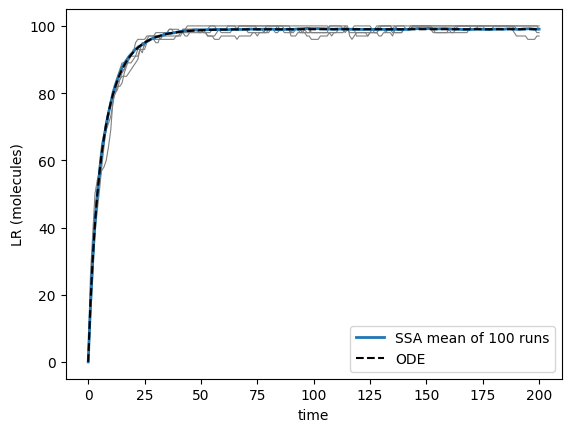

In [6]:
model.reset()   # start from the initial conditions
ssa = bngsim.Simulator(model, method="ssa")
reps = ssa.run_replicates(100, t_span=(0, 200), n_points=201, seed=1)
traj = np.array([r.observables['LR'] for r in reps])   # shape (replicates, times)

for x in traj[:5]:
    plt.plot(reps[0].time, x, color='gray', lw=0.8)
plt.plot(reps[0].time, traj.mean(axis=0), 'C0', lw=2, label='SSA mean of 100 runs')
plt.plot(res1.time, res1.observables['LR'], 'k--', label='ODE')
plt.xlabel("time")
plt.ylabel("LR (molecules)")
_ = plt.legend(loc='lower right')

With fewer molecules, noise is relatively larger. Reduce the ligand to 20 molecules:

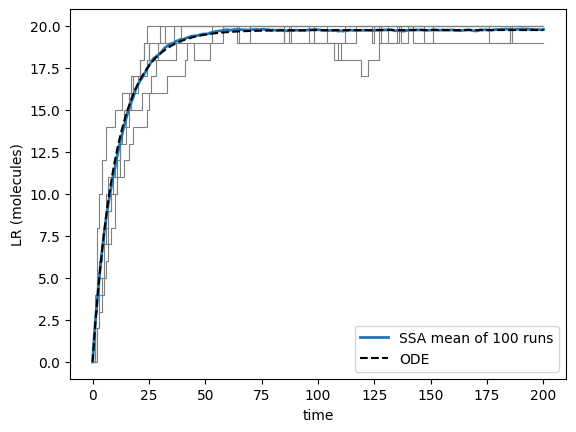

In [7]:
model.set_param('L0', 20)
model.reset()
reps = ssa.run_replicates(100, t_span=(0, 200), n_points=201, seed=1)
traj = np.array([r.observables['LR'] for r in reps])
model.reset()
ode = sim.run(t_span=(0, 200), n_points=201)
model.set_param('L0', defaults['L0'])

for x in traj[:5]:
    plt.plot(reps[0].time, x, color='gray', lw=0.8, drawstyle='steps-post')
plt.plot(reps[0].time, traj.mean(axis=0), 'C0', lw=2, label='SSA mean of 100 runs')
plt.plot(ode.time, ode.observables['LR'], 'k--', label='ODE')
plt.xlabel("time")
plt.ylabel("LR (molecules)")
_ = plt.legend(loc='lower right')